## Feature Engineering
Feature engineering on the raw data with rolling statistics, lag features, and rate of change to capture info.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

same as done in 1st notebook

In [2]:

def load_raw_data():
    df = None
    filepath = "../data/raw/CMAPSSData/train_FD001.txt"
    df = pd.read_csv(filepath,sep=r"\s+", header=None)
    df.columns = ["engine_id","cycle","op_setting_1","op_setting_2","op_setting_3"] + [f"s{i+1}" for i in range(df.shape[1] -5)] 
    
    return df


df_raw = load_raw_data()


df_var = df_raw.var()
low_var_cols = df_var[df_var<=1e-10].index.to_list()
df_raw = df_raw.drop(columns=low_var_cols)


def compute_rul(df):

    df['RUL'] = df.groupby('engine_id')['cycle'].transform('max') - df['cycle']  

    return df

df =  compute_rul(df_raw)

df.shape

(20631, 20)

### Identify Sensor Columns
Exclude non‑sensor columns (engine_id, cycle, operational settings, RUL) to get the list of sensors.

In [3]:

def get_sensor_cols(df):

    exclude = ["engine_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3", "RUL"]
    sensors_list = [col for col in df.columns if col not in exclude]
    
    return sensors_list   

sensor_cols = get_sensor_cols(df) 
print(sensor_cols)

['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


### Rolling Window Features
For each sensor, compute rolling mean and standard deviation over windows of 5, 10, and 30 cycles.  
These features smooth out noise and capture local trends.

In [4]:
def add_rolling_window_features(df, sensor_cols) :

    windows = [5, 10, 30]

    new_cols = {}
    for sensor in sensor_cols:
        for w in windows:
            grp = df.groupby("engine_id")[sensor]

            new_cols[f"{sensor}_roll_mean_{w}"] = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
            
            new_cols[f"{sensor}_roll_std_{w}"] = grp.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
    
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return df


df_rolling = add_rolling_window_features(df, sensor_cols)

print(f"Number of cols before : {df.shape[1]}")
print(f"Number of cols after adding rolling window : {df_rolling.shape[1]}")

Number of cols before : 20
Number of cols after adding rolling window : 110


### Visualising the Smoothing Effect
Compare sensor `s4` with its rolling mean `s4_roll_mean` column for `engine_id`- 1.

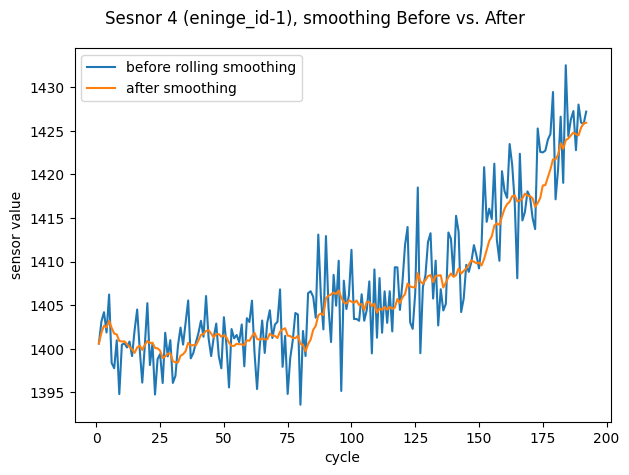

In [5]:
# smoothing effect

df_engine_1 = df[df['engine_id']==1]
df_rolling_engine_1 = df_rolling[df_rolling['engine_id']==1]

plt.plot(df_engine_1['cycle'], df_engine_1['s4'], label="before rolling smoothing")

plt.plot(df_rolling_engine_1['cycle'], df_rolling_engine_1['s4_roll_mean_10'], label="after smoothing")

plt.suptitle("Sesnor 4 (eninge_id-1), smoothing Before vs. After")
plt.xlabel("cycle")
plt.ylabel("sensor value")
plt.tight_layout()
plt.legend()
plt.show()

### Lag Features
Add lagged versions of each sensor (lag 1, 3, 5 cycles) to give the model information about recent history.

In [6]:
def add_lag_features(df, sensor_cols):

    lag_steps = [1, 3, 5]
    
    new_cols = {}
    for sensor in sensor_cols:
        for lag in lag_steps:
            new_cols[f"{sensor}_lag_{lag}"] = df.groupby("engine_id")[sensor].shift(lag)
    
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    return df

df_lag = add_lag_features(df_rolling, sensor_cols)
print(f"Before lag feature number of columns: {df_rolling.shape[1]}")
print(f"After lag feature number of columns: {df_lag.shape[1]}")

Before lag feature number of columns: 110
After lag feature number of columns: 155


### Rate of Change
Compute the first difference of each sensor (current - previous cycle) to capture instantaneous degradation speed.

In [7]:

def add_rate_of_change(df, sensor_cols):

    new_cols = {}
    for sensor in sensor_cols:
        new_cols[f"{sensor}_diff"] = df.groupby("engine_id")[sensor].diff().fillna(0)
    
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    return df


df_roc = add_rate_of_change(df_lag, sensor_cols)

print(f"Before adding rate of change number of columns: {df_lag.shape[1]}")
print(f"After adding rate of change number of columns: {df_roc.shape[1]}")

Before adding rate of change number of columns: 155
After adding rate of change number of columns: 170


In [8]:

print(f"Before feature engineering number of columns: {df.shape[1]}")
print(f"After feature engineering number of columns: {df_roc.shape[1]}")

Before feature engineering number of columns: 20
After feature engineering number of columns: 170
